In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
import math
from qiskit.quantum_info import DensityMatrix, Statevector

In [2]:
qasm_simulator = Aer.get_backend('qasm_simulator')
statevector_simulator = Aer.get_backend('statevector_simulator')

In [3]:
def run_on_simulators(circuit):
    compiled_circuit = transpile(circuit, backend=statevector_simulator)
    job = statevector_simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    statevec = result.get_statevector()
    num_qubits = circuit.num_qubits
    # r = [i for i in range(num_qubits)]
    # circuit.measure(r, r)
    circuit.measure_all()
    return result, statevec or Statevector([])

## 1. Quantum Teleportation

For Superdense coding, it is sending **2 classical bits** via **1 qubit** using the shared entanglement. Alice applies a gate and sends her qubit, and Bob decodes from it.

For Telportation, it is sending **1 qubit state** via **2 classical bits** using the shared entanglement. Alice measures and sents the 2 bits, and Bob applies the relevant corrections. _Think of it as the opposite action._

### 1.1 Setting a Qubit State

Let Alice set a Qubit state on q0 such that,

$
|\psi⟩ = a|0⟩ + b|1⟩
$

Bob's Qubit q2 would be entangled to q1, in which q1 measures q0.

### 1.2 Measurement of States

| | q0 | q2| Action | | | Result |
| -- | -- | -- | -- | -- | -- | -- |
| 00 | - | $\|00⟩$ | $I$ | $\|Φ+⟩ → a\|0⟩ + b\|1⟩$ | Apply nothing | $\hat{P}(0) = 1$. |
| 01 | Set $X$ | $\|01⟩$ | $X$ | $\|Ψ+⟩ → a\|1⟩ + b\|0⟩$ | Apply $X$ only | $\hat{P}(1) = 1$ (as it swaps $\|0⟩$ with $\|1⟩$) |
| 10 | Set $H$ | $\|10⟩$ | $Z$ | $\|Φ-⟩ → a\|0⟩ - b\|1⟩$ | Apply $Z$ only | $\hat{P}(1) \approx 0.5$ |
| 11 | Set $RZ(\frac{\pi}{5})$ and $RY(\frac{\pi}{3})$ | $\|11⟩$ | $X \cdot Z$ | $\|Ψ-⟩ → a\|1⟩ - b\|0⟩$ | Apply $X$ then $Z$ | $\hat{P}(0) \approx \frac{3}{4}$ and $\hat{P}(1) \approx \frac{1}{4}$ |

Apply the measurement from q0 to q1, which should result q2 to become the particular values.

##### Steps

1. **T0**: Set the Qubit state q0 to teleport
2. **T1**: Apply the entanglement from Alice teleport (q1) to Bob (q2)
3. **T2**: Apply the entanglement from Alice teleport (q1) to Alice state (q0)
4. **T3**: Start the measurement and teleportation. _For simulation, we do not use **if-controlled** gates but instead use deferred measurement in **T4**, and apply Z-Phase measurement from q0 to q2._ 

In [20]:
import numpy as np
from qiskit_aer import AerSimulator

In [21]:
class QuantumTeleportation:

    def __init__(self, message_bits):
        self.qc = QuantumCircuit(3, 3)
        # Step 1) Set the quantum state to teleport
        self.qc.barrier(label="T0")

        if message_bits == '00':
            pass 
        elif message_bits == '01':
            self.qc.x(0)
        elif message_bits == '10':
            self.qc.h(0)
        elif message_bits == '11':
            self.qc.ry(np.pi/3, 0)
            self.qc.rz(np.pi/5, 0)

    def teleport(self):
        self.qc.barrier(label="T1")
        self.qc.h(1)
        self.qc.cx(1, 2)

        self.qc.barrier(label="T2")
        self.qc.cx(0, 1)
        self.qc.h(0)
        # self.qc.barrier(label="measurement")
        # self.qc.measure(0, 0)
        # self.qc.measure(1, 1)

        self.qc.barrier(label="T3")

        # with self.qc.if_test((self.qc.clbits[1], 1)):
        #     self.qc.x(2)

        # with self.qc.if_test((self.qc.clbits[0], 1)):
        #     self.qc.z(2)

        # self.qc.barrier(label="simulator")
        self.qc.cx(1, 2)
        self.qc.cz(0, 2)

        # Deferred measurement
        self.qc.barrier(label="T4")
        self.qc.measure([0, 1], [0, 1])
        self.qc.measure([2], [2])

    def measure(self):
        backend = AerSimulator()
        # self.qc.save_statevector() # Snapshot the state after corrections
        qc_copy = self.qc.copy()
        result = backend.run(qc_copy).result()
        counts = result.get_counts()

        bucket = {'0':0, '1':0}
        for bitstring, n in counts.items():
            bucket[bitstring[0]] += n

        print(f"p0 = {(bucket['0'] / sum(counts.values())) * 100}%")
        print(f"p1 = {(bucket['1'] / sum(counts.values())) * 100}%")

        return plot_histogram(counts)
    

Teleport state for `00`,

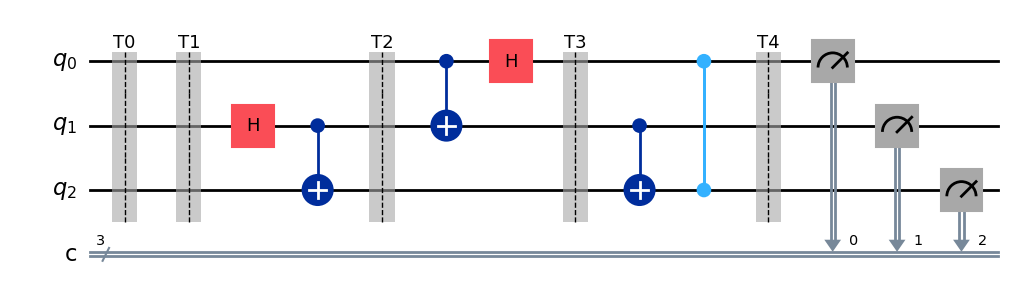

In [22]:
qt = QuantumTeleportation('00')
qt.teleport()
qt.qc.draw("mpl")

p0 = 100.0%
p1 = 0.0%


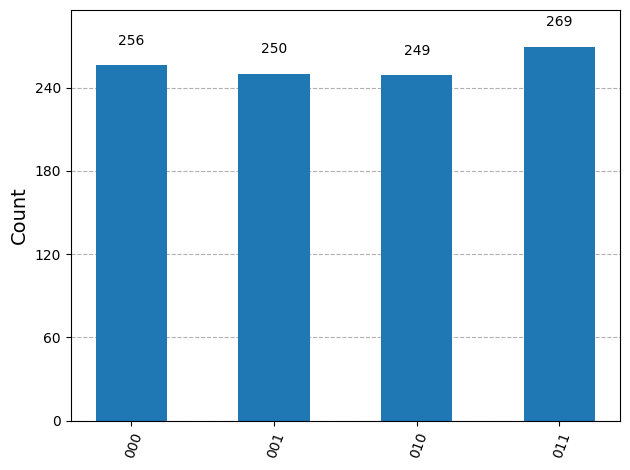

In [23]:
qt.measure()

Teleport state for `01`,

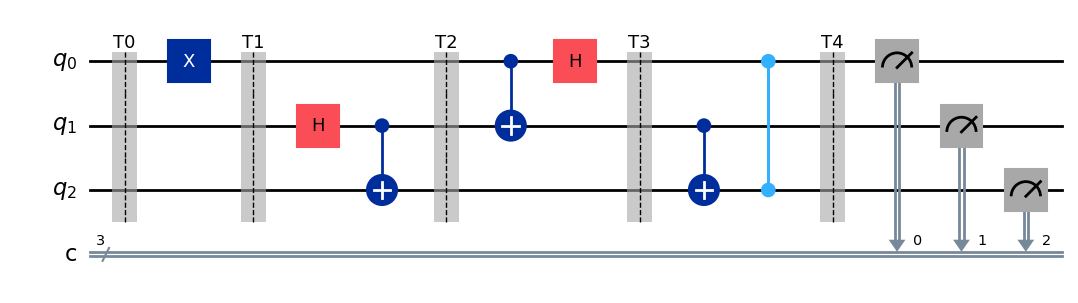

In [24]:
qt = QuantumTeleportation('01')
qt.teleport()
qt.qc.draw("mpl")

p0 = 0.0%
p1 = 100.0%


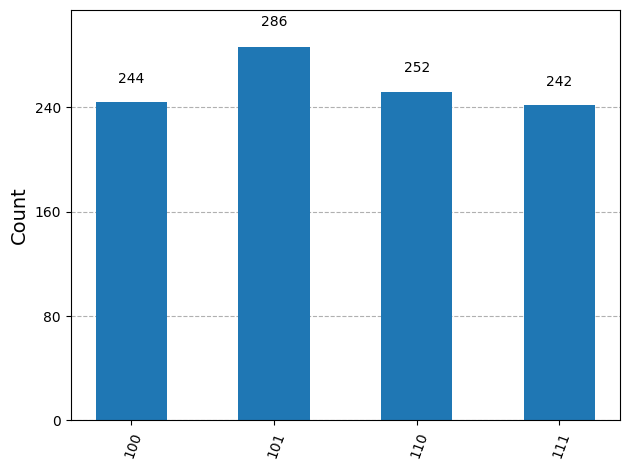

In [25]:
qt.measure()

Teleport state for `10`,

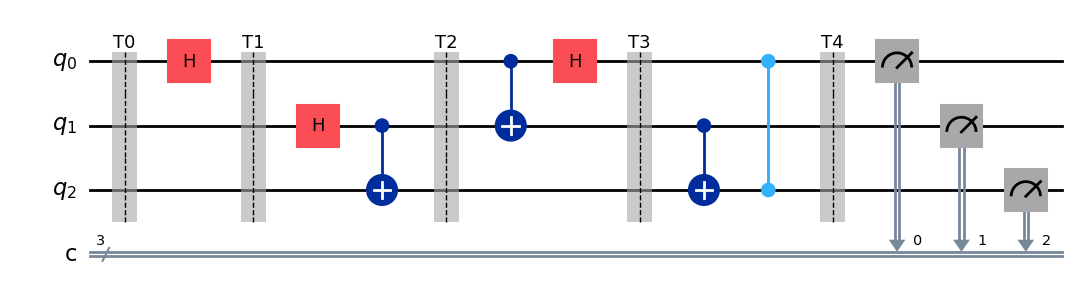

In [26]:
qt = QuantumTeleportation('10')
qt.teleport()
qt.qc.draw("mpl")

p0 = 52.24609375%
p1 = 47.75390625%


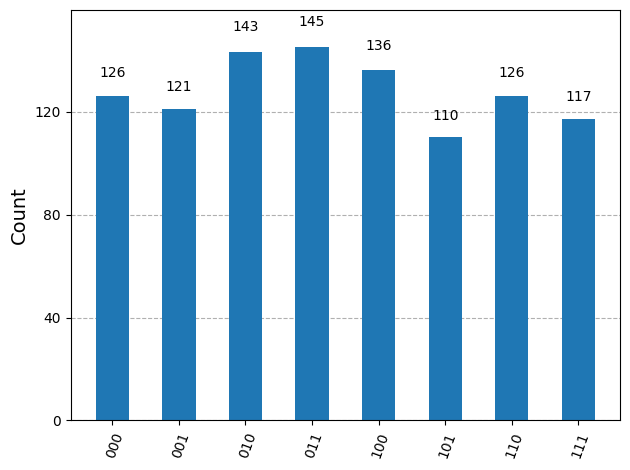

In [27]:
qt.measure()

Teleport state for `11`,

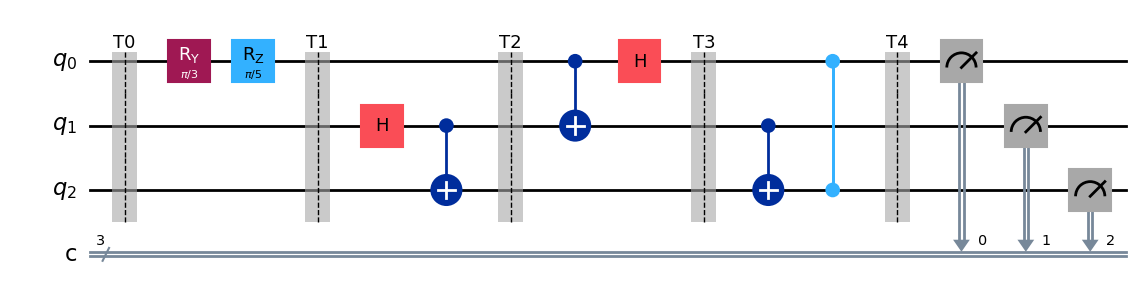

In [28]:
qt = QuantumTeleportation('11')
qt.teleport()
qt.qc.draw("mpl")

p0 = 74.8046875%
p1 = 25.1953125%


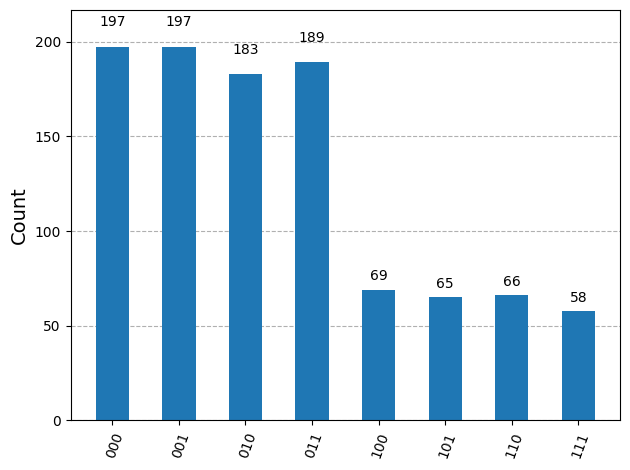

In [29]:
qt.measure()